## Imports

In [1]:
from   pathlib import Path
import matplotlib.pyplot as plt
import pickle
import torch
import pandas as pd
# import mlflow

from neuralhydrology.evaluation     import metrics
from neuralhydrology.nh_run         import start_run, eval_run
from neuralhydrology.datasetzoo     import register_dataset
from neuralhydrology.utils.config   import Config

from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)

# Custom functions plot_training_curves
from custom.functions.Plot import plot_training_curves, plot_validation_metrics
from custom.functions.Plot import plot_mape_horizon, plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series
from custom.functions.utils_fla import parse_neuralhydrology_log
from custom.functions.utils_fla import info_results, mape_array, dict_without_xr_key


## Parameters of the run

In [2]:
# Initialisation of the config file, name of the experiment in the parameter experiment_name
config_file = Path("config_explo1.yml")
cfg = Config(config_file)

# Here write the name of the run if renamed run or if you want to plot the specified run, otherwise will take the run_dir created during training
# example: "expName_TimeStamp" 
runFile = None 

# list of basins, DB -> name of the basin.txt where the name of the csv is indicated
basin = "massa_2"

# Whether you want to run a training, put false to plot your specific run folder for example
TRAIN, Evaluation_TEST = True, True

save_plots_training = True

## Run

In [3]:

if TRAIN:
    print("--- Starting the training of the model ---")
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        print("Using GPU")
        run_dir = start_run(config_file=Path(config_file))
    else:
        print("Using CPU")
        run_dir = start_run(config_file=Path(config_file), gpu=-1)
    print("==================================")
    print("  Training ended successfully !   ")
    print("==================================")
else: print(" Training step skipped !")
if runFile is not None:
    run_dir = Path(f"./runs/{runFile}")

if Evaluation_TEST:
    print("\nStarting the EVALUATION on the test period:  ")
    eval_run(run_dir=run_dir, period="test", from_best=cfg.save_best_enabled)
    print("==================================")
    print("  TEST ended successfully !   ")
    print("==================================")
else: print(" Testing process skipped !")

model_str = f"model_from_best"
testPath = Path(run_dir / "test" / f"{model_str}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)




--- Starting the training of the model ---
Using GPU
2025-11-06 15:49:47: Logging to c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\07_LSTM_HandoffSeq_v1\01_Tests_DB_massa2\Exploration\runs\explo1_0611_154947\output.log initialized.
2025-11-06 15:49:47: ### Folder structure created at c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\07_LSTM_HandoffSeq_v1\01_Tests_DB_massa2\Exploration\runs\explo1_0611_154947
2025-11-06 15:49:47: ### Run configurations for explo1


2025-11-06 15:49:47: experiment_name: explo1
2025-11-06 15:49:47: base_run_dir: runs
2025-11-06 15:49:47: img_log_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\07_LSTM_HandoffSeq_v1\01_Tests_DB_massa2\Exploration\runs\explo1_0611_154947\img_log
2025-11-06 15:49:47: train_dir: c:\Users\Kohler\Documents\NeuralHydrology_FK\neuralhydrology\test_Fla\Massa\07_LSTM_HandoffSeq_v1\01_Tests_DB_massa2\Exploration\runs\explo1_0611_154947\train_data
2025-11-06 15:49:47: seed: 42
2025-11-06 15:49:47: device: cuda:0
2025-11-06 15:49:47: num_workers: 16
2025-11-06 15:49:47: data_dir: ..\..\..\data
2025-11-06 15:49:47: dataset: swisshourly
2025-11-06 15:49:47: train_basin_file: ..\..\..\data\basins_2.txt
2025-11-06 15:49:47: validation_basin_file: ..\..\..\data\basins_2.txt
2025-11-06 15:49:47: test_basin_file: ..\..\..\data\basins_2.txt
2025-11-06 15:49:47: train_start_date: 2020-03-01 00:00:00
2025-11-06 15:49:47: train_end_date: 2023-02-28 00:00:00
2025-11-06 15:49

In [4]:
Metrics = dict_without_xr_key(results[basin]['1h'])
Metrics_ = Metrics.copy()

if cfg.save_in_csv and Evaluation_TEST:
    if Metrics_ is not None:
        summary_file =  Path(f"./{cfg.csv_metrics_name}.csv")
        Metrics_['experiment'] = run_dir.name

        summary_df = pd.DataFrame([Metrics_])
        
        # Append to summary file, creating it with a header if it doesn't exist
        summary_df.to_csv(f"{cfg.csv_metrics_name}.csv", mode='a', header=not summary_file.exists(), index=False)

---

In [5]:
print("Metrics on the cuncatenated last predictions, on the Evaluation period:")
print(Metrics)

Metrics on the cuncatenated last predictions, on the Evaluation period:
{'MAPE': 16.237506866455078, 'NSE': 0.950955331325531, 'MSE': 30.91771125793457, 'RMSE': 5.560369705148622}


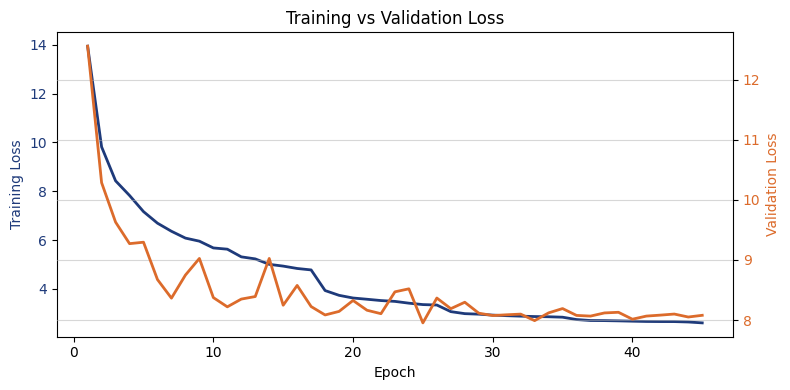

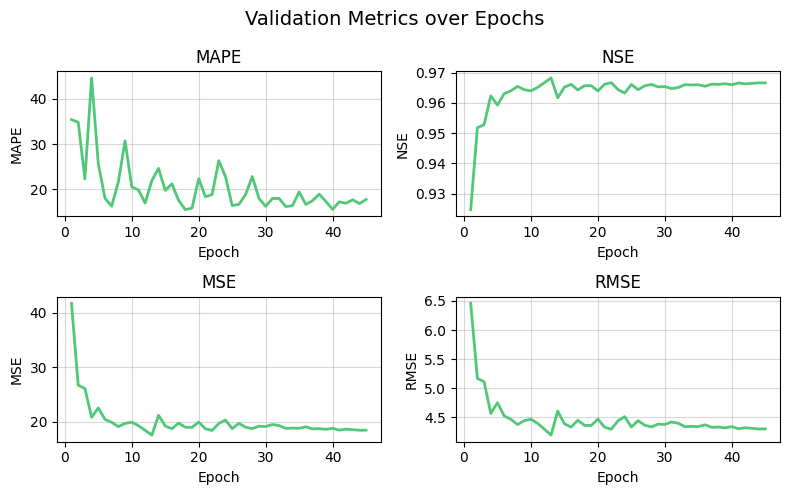

In [6]:
# Path to your output.log file
log_path = Path(f"{run_dir}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path, verbose=False)


plot_training_curves(train_df, val_df, save_fig = save_plots_training, run_dir=run_dir)
plot_validation_metrics(val_df, save_fig = save_plots_training, run_dir=run_dir)


---

### Extract results from Test period

In [7]:

results_ = results[basin]["1h"]["xr"]
scores = dict_without_xr_key(results[basin]['1h'])

# store only the values in numpy arrays from xarray DataArrays
y_true = results_['streamflow_obs']
y_pred = results_['streamflow_sim']

verb = False
if verb: 
    print("\n-- Calculating MAPE values for each horizon: --\n")
    mapes = mape_array(y_true, y_pred, verbose=verb)
    print("\n-- MAPE calculation per horizon completed. --\n")
else:
    mapes = mape_array(y_true, y_pred, verbose=verb)



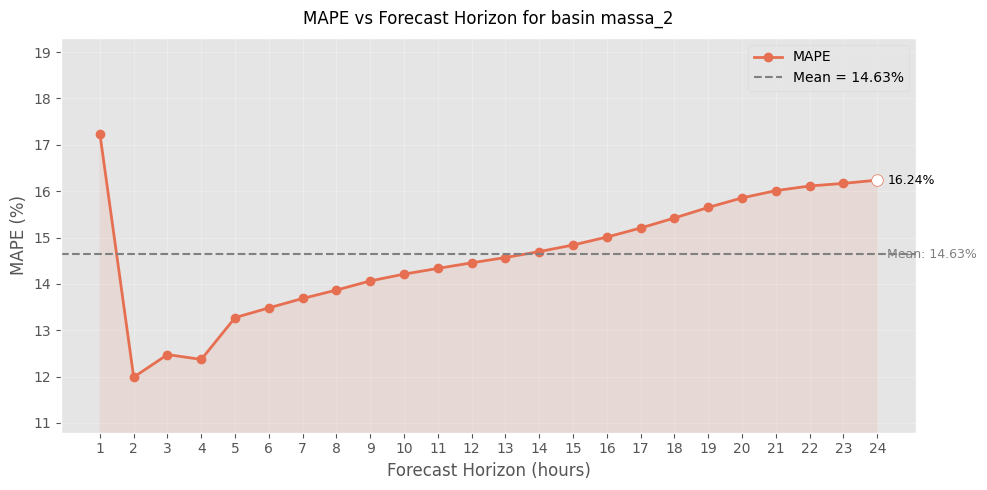

In [8]:
plot_mape_horizon(
    mapes,
    color="#e76f51",
    title=f"MAPE vs Forecast Horizon for basin {basin}"
)


In [9]:

scores_str = str.join(', ', [f"{key} : {scores[key]:.2f}" for key in scores])
title24 = f"Massa – {cfg.predict_last_n}h | " + scores_str

# plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[1, 6, cfg.predict_last_n])
plot_forecast_24h(measured=y_true, predicted=y_pred, title=title24, mode="list", horizons=[cfg.predict_last_n])


In [10]:
# Example: visualize forecast issued on April 10, 2024, at midnight
# plot_forecast_horizon_24h(
#     issue_date="2024-08-10 00:00:00",
#     xr_ds=results_
# ).show()
# plot_forecast_horizon_24h(
#     issue_date="2024-08-10 01:00:00",
#     xr_ds=results_
# ).show()

In [11]:
# Example to plot the forecast issued at the given time stamp and the n_forecast next predictions
# plot_forecast_horizon_series(
#     issue_date="2024-06-10 00:00:00",
#     xr_ds=results_,
#     n_forecasts=10
# ).show()

---

## Computation of all metric scores - TEST period


### Prediction at $t+24h$

In [12]:
qobs=results_['streamflow_obs']
qsim=results_['streamflow_sim']
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))

for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.951
MSE: 30.918
RMSE: 5.560
KGE: 0.902
Alpha-NSE: 0.926
Beta-KGE: 0.940
Beta-NSE: -0.046
Pearson-r: 0.978
FHV: -8.374
FMS: -4.015
FLV: -18.289
Peak-Timing: nan
Peak-MAPE: 21.303
MAPE: 16.238


### Prediction at $t+7h$

In [13]:
values = metrics.calculate_all_metrics(qobs.isel(time_step=6), qsim.isel(time_step=6))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.973
MSE: 16.583
RMSE: 4.072
KGE: 0.950
Alpha-NSE: 0.963
Beta-KGE: 0.969
Beta-NSE: -0.024
Pearson-r: 0.987
FHV: -1.599
FMS: -3.602
FLV: -39.901
Peak-Timing: nan
Peak-MAPE: 14.656
MAPE: 13.685
